<a href="https://colab.research.google.com/github/sankeawthong/Project-1-Lita-Chatbot/blob/main/Lab07_Ensembles%20(Assignment).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 7 — One Model vs the Crowd

**Machine Learning · Week 7 · School of Information Technology**

| | |
|---|---|
| **Time budget** | ~2 hours (in-lab) |
| **Learning objectives** | 1. Build and evaluate bagging and boosting ensembles — 2. Use out-of-bag scoring and interpret it against cross-validation — 3. Tune interacting hyperparameters with grid search — 4. Compare importance across model families and judge whether an ensemble earned its cost — |
| **Dataset** | Breast Cancer Wisconsin (569 tumours, 30 features) — the same data as Lab 4, so today's numbers are directly comparable |
| **Grading** | Exercises 1–6 + AI-usage disclosure · self-checks give instant feedback |

> **The point of today is not "ensembles win."** It is to measure *how much* they win by, *what they cost*, and *what you give up*. A 4-point accuracy gain that costs 75× the training time is a decision — not a free lunch.

⚠️ **First:** File → Save a copy in Drive, rename to `Lab7_<your_student_id>`.

---
## Setup

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report
import xgboost as xgb

RNG_SEED = 42
np.random.seed(RNG_SEED)

data = load_breast_cancer()
X, y = data.data, data.target
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RNG_SEED)
print(f"train {X_tr.shape} | test {X_te.shape} (locked away until the very end)")
print(f"xgboost version {xgb.__version__}")

train (426, 30) | test (143, 30) (locked away until the very end)
xgboost version 3.4.1


---
## Part 1 · The baseline: one tuned tree

**Never report an ensemble without a baseline.** The interesting question is never "is my forest good?" — it is "how much better is my forest than something simple?"

We'll tune a single decision tree properly, so the comparison is fair. A tuned tree beaten by an ensemble is evidence; an untuned tree beaten by an ensemble is a rigged fight.

In [2]:
tree_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RNG_SEED),
    {"max_depth": [2, 3, 4, 5, 6, None], "min_samples_leaf": [1, 3, 5, 10]},
    cv=5, n_jobs=-1)
tree_grid.fit(X_tr, y_tr)

tree = tree_grid.best_estimator_
print(f"best parameters : {tree_grid.best_params_}")
print(f"CV accuracy     : {tree_grid.best_score_:.4f}")
print(f"leaves          : {tree.get_n_leaves()},  depth {tree.get_depth()}")
print("\nThis is the number to beat.")

best parameters : {'max_depth': 5, 'min_samples_leaf': 3}
CV accuracy     : 0.9344
leaves          : 11,  depth 5

This is the number to beat.


---
## Part 2 · Random Forest, and the free validation set

Bagging trees, plus a random feature subset at every split. And because each tree misses about 37% of the rows, those left-out rows form a ready-made validation set — **out-of-bag scoring**, free of charge.

In [3]:
rf = RandomForestClassifier(n_estimators=300, oob_score=True,
                            random_state=RNG_SEED, n_jobs=-1).fit(X_tr, y_tr)

rf_cv = cross_val_score(RandomForestClassifier(n_estimators=300, random_state=RNG_SEED, n_jobs=-1),
                        X_tr, y_tr, cv=5)

print(f"out-of-bag score      : {rf.oob_score_:.4f}   (free — no extra fitting)")
print(f"5-fold CV accuracy    : {rf_cv.mean():.4f} ± {rf_cv.std():.4f}   (5 extra forests)")
print(f"difference            : {abs(rf.oob_score_ - rf_cv.mean()):.4f}")
print(f"\ntuned single tree CV : {tree_grid.best_score_:.4f}")
print(f"improvement from bagging: {rf_cv.mean() - tree_grid.best_score_:+.4f}")

out-of-bag score      : 0.9624   (free — no extra fitting)
5-fold CV accuracy    : 0.9624 ± 0.0203   (5 extra forests)
difference            : 0.0000

tuned single tree CV : 0.9344
improvement from bagging: +0.0280


**Look at how closely OOB and CV agree.** That is the point of out-of-bag scoring: it gives you an honest estimate of generalization performance without fitting five extra forests. For a large model on a big dataset, that is a real saving — and it's a nice thing to mention in your project report.

Two cautions: OOB is only available for bagging methods (there are no left-out rows in boosting), and it still isn't a substitute for your final held-out test set.

---
## Part 3 · How many trees?

The lecture claimed adding trees to a forest reduces variance and then stops helping — but never hurts. Let's find where the curve flattens.

/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


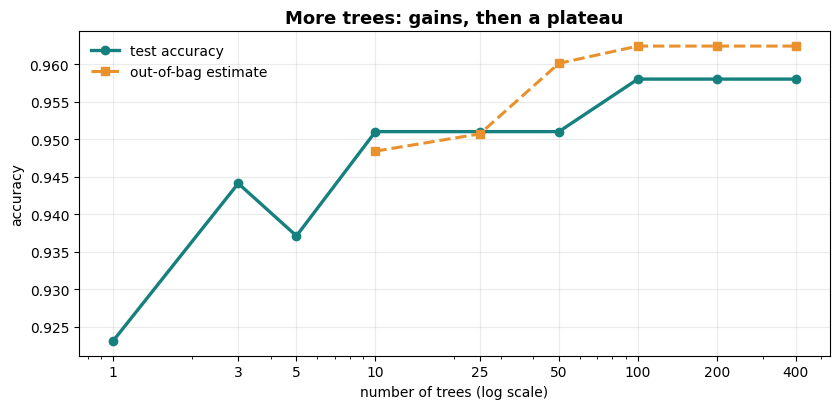

,n_estimators,OOB,test
0,1,NaN,0.9231
1,3,NaN,0.9441
2,5,NaN,0.9371
3,10,0.9484,0.9510
4,25,0.9507,0.9510
5,50,0.9601,0.9510
6,100,0.9624,0.9580
7,200,0.9624,0.9580
8,400,0.9624,0.9580


In [4]:
sweep = []
for n in [1, 3, 5, 10, 25, 50, 100, 200, 400]:
    m = RandomForestClassifier(n_estimators=n, oob_score=(n >= 10),
                               random_state=RNG_SEED, n_jobs=-1).fit(X_tr, y_tr)
    sweep.append({"n_estimators": n,
                  "OOB": round(m.oob_score_, 4) if n >= 10 else None,
                  "test": round(m.score(X_te, y_te), 4)})
sweep_df = pd.DataFrame(sweep)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(sweep_df["n_estimators"], sweep_df["test"], marker="o", lw=2.4,
        color="#15807E", label="test accuracy")
ok = sweep_df.dropna(subset=["OOB"])
ax.plot(ok["n_estimators"], ok["OOB"], marker="s", lw=2.2, ls="--",
        color="#E8912D", label="out-of-bag estimate")
ax.set_xscale("log"); ax.set_xticks(sweep_df["n_estimators"])
ax.set_xticklabels(sweep_df["n_estimators"])
ax.set_xlabel("number of trees (log scale)"); ax.set_ylabel("accuracy")
ax.set_title("More trees: gains, then a plateau", fontsize=13, fontweight="bold")
ax.legend(frameon=False); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

sweep_df

Read it honestly: most of the gain arrives in the first 10–25 trees, and past ~100 the curve is flat. **More trees never made it worse** — they just stopped helping, while costing linearly more time.

That is why `n_estimators` is a *safe* knob on a forest. It is also why "I used 5000 trees" is not an achievement.

---
## Part 4 · XGBoost, tuned properly

Boosting's extra accuracy comes with three interacting knobs. `learning_rate` and `n_estimators` trade off almost exactly — halve one, double the other — so they must be searched **together**.

In [5]:
xgb_grid = GridSearchCV(
    xgb.XGBClassifier(eval_metric="logloss", random_state=RNG_SEED, verbosity=0),
    {"n_estimators":  [100, 300],
     "learning_rate": [0.05, 0.1, 0.3],
     "max_depth":     [2, 3, 5]},
    cv=5, n_jobs=-1)
xgb_grid.fit(X_tr, y_tr)

xgb_best = xgb_grid.best_estimator_
print(f"best parameters : {xgb_grid.best_params_}")
print(f"CV accuracy     : {xgb_grid.best_score_:.4f}")
print(f"combinations    : {len(xgb_grid.cv_results_['params'])} × 5 folds "
      f"= {len(xgb_grid.cv_results_['params'])*5} fits")

print("\n--- CV leaderboard so far (training data only) ---")
print(f"  tuned decision tree : {tree_grid.best_score_:.4f}")
print(f"  random forest       : {rf_cv.mean():.4f}")
print(f"  xgboost (tuned)     : {xgb_grid.best_score_:.4f}")

best parameters : {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
CV accuracy     : 0.9671
combinations    : 18 × 5 folds = 90 fits

--- CV leaderboard so far (training data only) ---
  tuned decision tree : 0.9344
  random forest       : 0.9624
  xgboost (tuned)     : 0.9671


> **Notice which learning rate won**, and pair it with the number of trees. A low learning rate takes small steps, so it needs more of them — exactly the trade-off from the lecture. Searching either one alone would have missed the best combination.

---
## Part 5 · Three models, three importance stories

All three can rank features. They will not agree — and understanding *why* is more useful than any single ranking.

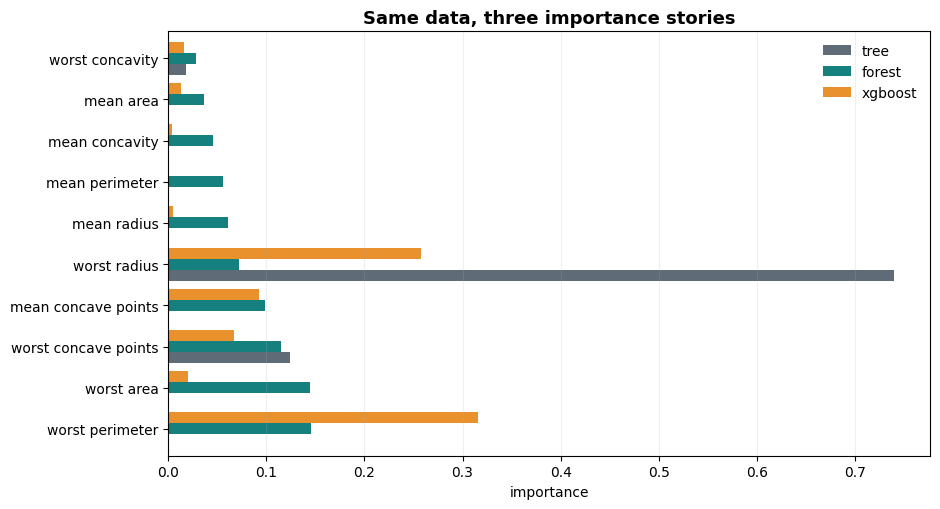

How concentrated is each story?

  tree     top feature 0.740 (worst radius          ) | top-3 total 0.913 | features at exactly zero: 21/30
  forest   top feature 0.146 (worst perimeter       ) | top-3 total 0.404 | features at exactly zero: 0/30
  xgboost  top feature 0.316 (worst perimeter       ) | top-3 total 0.666 | features at exactly zero: 1/30


In [6]:
imp = pd.DataFrame({
    "feature": data.feature_names,
    "tree":    tree.feature_importances_,
    "forest":  rf.feature_importances_,
    "xgboost": xgb_best.feature_importances_,
})
top10 = imp.set_index("feature").loc[imp.set_index("feature")["forest"].nlargest(10).index]

ax = top10.plot.barh(figsize=(9.5, 5.2), width=.8,
                     color={"tree": "#5F6B76", "forest": "#15807E", "xgboost": "#E8912D"})
ax.set_xlabel("importance"); ax.set_ylabel("")
ax.set_title("Same data, three importance stories", fontsize=13, fontweight="bold")
ax.legend(frameon=False); ax.grid(alpha=.2, axis="x")
plt.tight_layout(); plt.show()

print("How concentrated is each story?\n")
for name in ["tree", "forest", "xgboost"]:
    v = imp[name].values
    print(f"  {name:8s} top feature {v.max():.3f} ({imp['feature'][v.argmax()]:22s}) "
          f"| top-3 total {np.sort(v)[-3:].sum():.3f} | features at exactly zero: {int((v == 0).sum())}/30")

**The single tree is the outlier, and that is the lesson.** It concentrates most of its importance on one feature and assigns *exactly zero* to most of the rest — not because those features are uninformative, but because a tree uses a feature at a split and then moves on. It never gets the chance to reveal that "worst perimeter" would also have worked.

The forest, having hundreds of trees each restricted to a random feature subset, distributes credit across the correlated family (radius / perimeter / area). That is a more faithful picture of what the data contains — and it is why forest importances are more stable than a single tree's.

> For a claim you'll defend in a report, use **permutation importance** (shuffle a column, measure the damage). It is model-agnostic and measures what the model actually relies on, rather than how the training algorithm happened to allocate credit.

---
## Part 6 · ⚖️ The honest verdict: accuracy AND cost

Now the question the lecture asked. Was the ensemble worth it? Accuracy alone cannot answer that — so we time them too.

**This is also our single touch of the test set.**

In [7]:
def time_fit(make_model, repeats=3):
    t0 = time.perf_counter()
    for _ in range(repeats):
        m = make_model().fit(X_tr, y_tr)
    return (time.perf_counter() - t0) / repeats, m

rows = []
for name, maker in [
    ("Decision tree (tuned)", lambda: DecisionTreeClassifier(**tree_grid.best_params_, random_state=RNG_SEED)),
    ("Random Forest (300)",   lambda: RandomForestClassifier(n_estimators=300, random_state=RNG_SEED, n_jobs=-1)),
    ("XGBoost (tuned)",       lambda: xgb.XGBClassifier(**xgb_grid.best_params_, eval_metric="logloss",
                                                        random_state=RNG_SEED, verbosity=0)),
]:
    fit_s, model = time_fit(maker)
    pred = model.predict(X_te)
    rows.append({"model": name,
                 "fit time (ms)": round(fit_s * 1000, 1),
                 "test accuracy": round(accuracy_score(y_te, pred), 4),
                 "test F1": round(f1_score(y_te, pred), 4)})

verdict = pd.DataFrame(rows)
base_t = verdict.loc[0, "fit time (ms)"]; base_a = verdict.loc[0, "test accuracy"]
verdict["time vs tree"] = (verdict["fit time (ms)"] / base_t).round(1).astype(str) + "×"
verdict["accuracy gain"] = (verdict["test accuracy"] - base_a).round(4)
print(verdict.to_string(index=False))

                model  fit time (ms)  test accuracy  test F1 time vs tree  accuracy gain
Decision tree (tuned)            9.6         0.9161   0.9318         1.0×         0.0000
  Random Forest (300)          707.1         0.9580   0.9670        73.7×         0.0419
      XGBoost (tuned)          160.9         0.9580   0.9670        16.8×         0.0419


**Read the last two columns together, and be honest about what they say.**

The ensembles do beat the tuned tree — a real, worthwhile gain on a medical dataset where each point matters. But they cost *orders of magnitude* more training time to get it. On 426 rows that is milliseconds and nobody cares. On ten million rows, the same ratio is the difference between a coffee break and an overnight job.

And notice whether the forest and XGBoost actually separate on the test set. If they land within a point of each other, the honest sentence is **"they are equivalent here"** — not "XGBoost won." A 0.4-point difference on 143 test samples is less than one patient.

> **The report sentence you are aiming for:** *"The Random Forest improved test accuracy over a tuned decision tree by X points at Y× the training cost; XGBoost matched it. Given the deployment constraints, we chose ___ because ___."* That paragraph earns marks. A bare accuracy number does not.

---
---
# 🏋️ Exercises (graded)

Replace each `...`, run every ✅ self-check, complete the disclosure. Be ready to explain any line orally.

### Exercise 1 — Where does 63% come from?
A bootstrap sample draws `n` rows **with replacement** from `n` rows. Verify the lecture's claim empirically:
- **`unique_fraction`** — draw one bootstrap sample of `len(X_tr)` indices and compute the fraction of the original rows that appear **at least once**
- **`mean_unique`** — repeat 200 times and take the mean fraction

In [ ]:
rng = np.random.default_rng(0)
n = len(X_tr)
idx = rng.integers(0, n, n)
unique_fraction = ...
mean_unique = ...
print(f'one sample: {unique_fraction:.4f} | mean of 200: {mean_unique:.4f} | theory: {1 - 1/np.e:.4f}')

In [ ]:
# ✅ Self-check — Exercise 1
assert 0.55 < unique_fraction < 0.70, "About 63% of rows should appear at least once."
assert abs(mean_unique - (1 - 1/np.e)) < 0.02, "The mean should sit very close to 1 - 1/e = 0.632."
print(f"Exercise 1 self-check passed ✔  (mean {mean_unique:.4f} vs theory {1-1/np.e:.4f})")
print("The other ~37% are the out-of-bag rows — which is exactly why OOB scoring works.")

### Exercise 2 — OOB as a cheap validation set
Build **`rf100`** — a `RandomForestClassifier` with 100 trees, `oob_score=True`, `random_state=RNG_SEED` — fit it on the training data, and record:
- **`oob`** — its out-of-bag score
- **`cv_mean`** — the 5-fold CV mean for the same configuration (without `oob_score`)
- **`gap`** — the absolute difference between them

In [ ]:
rf100 = ...
oob = ...
cv_mean = ...
gap = ...
print(f'OOB {oob:.4f} | CV {cv_mean:.4f} | gap {gap:.4f}')

In [ ]:
# ✅ Self-check — Exercise 2
assert rf100.get_params()["oob_score"] is True, "You need oob_score=True to get an OOB estimate."
assert rf100.get_params()["n_estimators"] == 100, "Use 100 trees."
assert gap < 0.05, "OOB and CV should agree closely — that is the whole point of OOB."
print(f"Exercise 2 self-check passed ✔  (OOB {oob:.4f}, CV {cv_mean:.4f}, gap {gap:.4f})")
print("One fit gave you what five fits gave you. On a big dataset, that is real money.")

### Exercise 3 — Where does the gain flatten?
Using `sweep_df` from Part 3:
- **`best_test`** — the highest test accuracy reached anywhere in the sweep
- **`n_enough`** — the SMALLEST `n_estimators` whose test accuracy is within 0.005 of `best_test`
- **`wasted_ratio`** — how many times more trees the largest setting uses compared with `n_enough`

In [ ]:
best_test = ...
n_enough = ...
wasted_ratio = ...
print(f'best {best_test:.4f} | enough at n={n_enough} | largest setting uses {wasted_ratio:.0f}x more trees')

In [ ]:
# ✅ Self-check — Exercise 3
_bt = sweep_df["test"].max()
assert abs(best_test - _bt) < 1e-9, "best_test is the maximum test accuracy in the sweep."
assert n_enough == int(sweep_df.loc[sweep_df["test"] >= _bt - 0.005, "n_estimators"].min()), \
    "Take the SMALLEST n_estimators that gets within 0.005 of the best."
assert wasted_ratio > 1, "The largest setting should use more trees than you actually need."
print(f"Exercise 3 self-check passed ✔")
print(f"  {n_enough} trees is as good as {int(sweep_df['n_estimators'].max())} — {wasted_ratio:.0f}x the compute for nothing.")
print("  'More trees never hurts accuracy' is true. 'More trees is free' is not.")

### Exercise 4 — The learning-rate / n_estimators trade
From `xgb_grid.cv_results_`, examine how the two parameters interact:
- **`best_lr`**, **`best_n`** — the winning learning rate and tree count
- **`low_lr_best_n`** — among all results with the LOWEST learning rate tried, the `n_estimators` of the best-scoring one
- **`high_lr_best_n`** — the same, among results with the HIGHEST learning rate tried

In [ ]:
res = pd.DataFrame(xgb_grid.cv_results_['params'])
res['score'] = xgb_grid.cv_results_['mean_test_score']
best_lr = ...
best_n = ...
lo, hi = res['learning_rate'].min(), res['learning_rate'].max()
low_lr_best_n = ...
high_lr_best_n = ...
print(f'best: lr={best_lr}, n={best_n}')
print(f'at lr={lo} the best n is {low_lr_best_n}; at lr={hi} the best n is {high_lr_best_n}')

In [ ]:
# ✅ Self-check — Exercise 4
_r = pd.DataFrame(xgb_grid.cv_results_["params"]); _r["score"] = xgb_grid.cv_results_["mean_test_score"]
assert best_lr == xgb_grid.best_params_["learning_rate"], "Read best_lr from grid.best_params_."
assert best_n == xgb_grid.best_params_["n_estimators"], "Read best_n from grid.best_params_."
assert low_lr_best_n >= high_lr_best_n, \
    "A LOWER learning rate takes smaller steps, so it should want at least as many trees."
print(f"Exercise 4 self-check passed ✔")
print(f"  lower learning rate → wants {low_lr_best_n} trees; higher → wants {high_lr_best_n}")
print("  That is why these two must be searched TOGETHER, never one at a time.")

### Exercise 5 — How concentrated is the story?
Quantify the difference between the tree's and the forest's importance rankings:
- **`tree_top_share`** — the share of total importance taken by the single tree's top feature
- **`forest_top_share`** — the same for the forest
- **`tree_zeros`**, **`forest_zeros`** — how many features each assigns *exactly* zero importance

In [ ]:
tree_top_share = ...
forest_top_share = ...
tree_zeros = ...
forest_zeros = ...
print(f'tree   top {tree_top_share:.3f} | zeros {tree_zeros}/30')
print(f'forest top {forest_top_share:.3f} | zeros {forest_zeros}/30')

In [ ]:
# ✅ Self-check — Exercise 5
assert abs(tree_top_share - tree.feature_importances_.max()) < 1e-9
assert abs(forest_top_share - rf.feature_importances_.max()) < 1e-9
assert tree_top_share > forest_top_share, "A single tree concentrates importance far more than a forest."
assert tree_zeros > forest_zeros, "A single tree uses only a handful of features; a forest touches nearly all of them."
print(f"Exercise 5 self-check passed ✔")
print(f"  the tree gives {tree_top_share:.0%} of all importance to ONE feature and ignores {tree_zeros} of 30 entirely")
print(f"  the forest's top feature gets {forest_top_share:.0%}, and it ignores only {forest_zeros}")
print("  Same data. 'Unimportant' in the tree's story mostly means 'never got the chance'.")

### Exercise 6 — Open-ended: one honest investigation
Pick **one**, carry it out properly (CV on training data, mean ± spread), and write it up:

**(a)** **Does `max_features` matter?** Fit forests with `max_features` set to `'sqrt'`, `0.5`, and `None` (all features). Does removing the feature-randomness measurably hurt? That parameter is what makes a forest a *forest* — test the claim.

**(b)** **Boosting and label noise.** Flip 10% of the training labels at random, then refit the tuned tree, the forest and XGBoost. Which degrades most? The lecture claimed boosting is more vulnerable — check it.

**(c)** **Does a voting ensemble beat its members?** Build a soft-voting ensemble of three *different* families (e.g. logistic regression, Random Forest, SVM with `probability=True` — remember to scale where needed) and compare its CV score against each member alone.

Then write **3+ sentences**: what you did, what you found, and one caveat about what your evidence does *not* establish.

In [ ]:
# your investigation here — (a), (b) or (c)
...

*Your write-up (≥ 3 sentences): what you did · what you found · one caveat.*

✍️ ...

---
## 🧾 AI-usage disclosure (required)

> **AI tools used:** *e.g., "Claude — explained what oob_score_ measures; helped debug my Exercise 4 pandas filtering" — or — "None."*
>
> **Written and understood by:** *your name & student ID*
>
> I can explain every line of code in this notebook.

## 📤 Submitting

1. **Runtime → Restart session and run all** — clean run, every self-check *passed*.
2. Disclosure filled, notebook renamed `Lab7_<student_id>`.
3. **File → Download → .ipynb** → upload to the MS Team.

---
*Dataset: Breast Cancer Wisconsin (Diagnostic), UCI Machine Learning Repository, via scikit-learn.*